In [2]:
# First, I'll import all the necessary libraries for our Dask ML implementation
import dask.dataframe as dd
from dask_ml.preprocessing import LabelEncoder, StandardScaler
from dask_ml.model_selection import train_test_split
from dask_ml.wrappers import ParallelPostFit
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from dask_ml.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

In [3]:
# Load the Iris dataset using Dask DataFrame
# Note: Adjust the path if needed for your environment
iris_df = dd.read_csv("iris.csv")

# Display the first few rows to verify the data
print("First 5 rows of the dataset:")
display(iris_df.head())

# Check data types and info
print("\nDataset information:")
display(iris_df.dtypes)

First 5 rows of the dataset:


,sepal_length,sepal_width,petal_length,petal_width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa



Dataset information:


sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
variety          object
dtype: object

In [4]:
# Encode the categorical labels (variety) to numeric values
label_encoder = LabelEncoder()
iris_df['label'] = label_encoder.fit_transform(iris_df['variety'])

# Display the mapping between original labels and encoded values
print("Label mapping:")
unique_varieties = iris_df['variety'].unique().compute()
unique_labels = iris_df['label'].unique().compute()
for v, l in zip(unique_varieties, unique_labels):
    print(f"  {v} -> {l}")

# Extract features and target variable
features = iris_df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
labels = iris_df['label']

# Split data into training (90%) and testing (10%) sets for consistency with Part A
X_train, X_test, y_train, y_test = train_test_split(
    features, labels, 
    test_size=0.1, 
    random_state=42  # Using the same random seed as Part A for fair comparison
)

print(f"\nTraining set size: {len(X_train.compute())} samples")
print(f"Test set size: {len(X_test.compute())} samples")

Label mapping:
  Setosa -> 0
  Versicolor -> 1
  Virginica -> 2

Training set size: 136 samples
Test set size: 14 samples


/home/coolmax/anaconda3/envs/pyspark_env/lib/python3.8/site-packages/dask_ml/model_selection/_split.py:464: FutureWarning: The default value for 'shuffle' must be specified when splitting DataFrames. In the future DataFrames will automatically be shuffled within blocks prior to splitting. Specify 'shuffle=True' to adopt the future behavior now, or 'shuffle=False' to retain the previous behavior.
  warnings.warn(


In [5]:
# Create a scaler for feature standardization
scaler = StandardScaler()

# Define different classifiers for comparison
dt = DecisionTreeClassifier(max_depth=4, random_state=42)  # Same max_depth as Part A
rf = RandomForestClassifier(n_estimators=10, random_state=42)
gbt = GradientBoostingClassifier(n_estimators=10, max_depth=4, random_state=42)

# Create scikit-learn pipelines for each model
# Each pipeline first standardizes the data, then applies the classifier
pipeline_dt = make_pipeline(scaler, dt)
pipeline_rf = make_pipeline(scaler, rf)
pipeline_gbt = make_pipeline(scaler, gbt)

# Wrap with Dask's ParallelPostFit for distributed prediction
model_dt = ParallelPostFit(estimator=pipeline_dt)
model_rf = ParallelPostFit(estimator=pipeline_rf)
model_gbt = ParallelPostFit(estimator=pipeline_gbt)

print("Pipelines created for all three classifiers")

Pipelines created for all three classifiers


In [6]:
# Function to train models and evaluate their performance
def train_and_evaluate(model, X_train, X_test, y_train, y_test, model_name):
    print(f"\n--- Training {model_name} ---")
    
    # Record the start time
    start_time = time.time()
    
    # Train the model
    print("Fitting the model...")
    model.fit(X_train, y_train)
    
    # Make predictions
    print("Generating predictions...")
    y_pred = model.predict(X_test)
    
    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    
    # Calculate training time
    training_time = time.time() - start_time
    
    print(f"Training completed in {training_time:.2f} seconds")
    print(f"Test accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    
    return accuracy, y_pred, training_time


--- Training Decision Tree ---
Fitting the model...
Generating predictions...
Training completed in 0.08 seconds
Test accuracy: 1.0000 (100.00%)


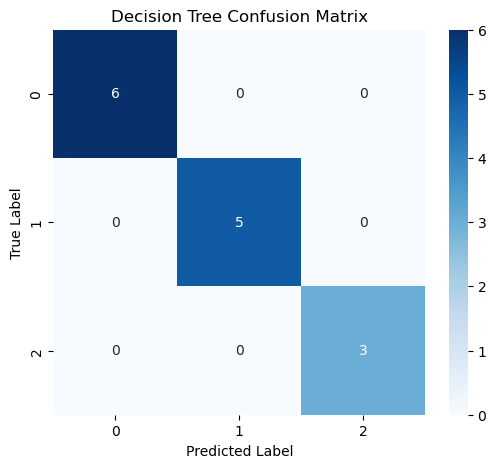

In [7]:
# Train and evaluate the Decision Tree model
dt_accuracy, dt_predictions, dt_time = train_and_evaluate(
    model_dt, X_train, X_test, y_train, y_test, "Decision Tree"
)

# Compute and display confusion matrix
y_true = y_test.compute()
y_pred_dt = dt_predictions.compute()
dt_cm = confusion_matrix(y_true, y_pred_dt)

plt.figure(figsize=(6, 5))
sns.heatmap(dt_cm, annot=True, fmt='d', cmap='Blues')
plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


--- Training Random Forest ---
Fitting the model...
Generating predictions...
Training completed in 0.10 seconds
Test accuracy: 1.0000 (100.00%)


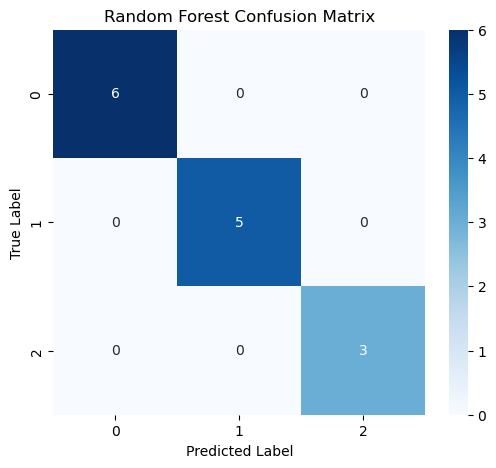

In [8]:
# Train and evaluate the Random Forest model
rf_accuracy, rf_predictions, rf_time = train_and_evaluate(
    model_rf, X_train, X_test, y_train, y_test, "Random Forest"
)

# Compute and display confusion matrix
y_pred_rf = rf_predictions.compute()
rf_cm = confusion_matrix(y_true, y_pred_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


--- Training Gradient Boosting ---
Fitting the model...
Generating predictions...
Training completed in 0.10 seconds
Test accuracy: 1.0000 (100.00%)


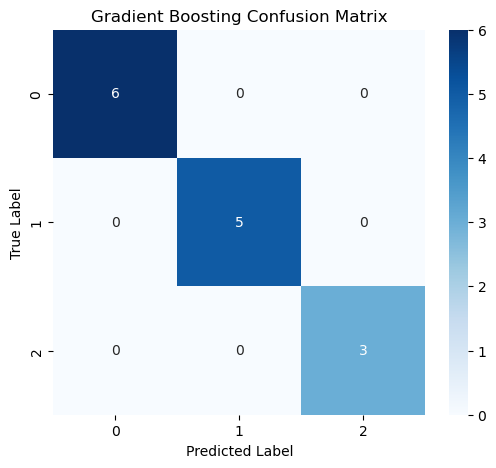

In [9]:
# Train and evaluate the Gradient Boosting model
gbt_accuracy, gbt_predictions, gbt_time = train_and_evaluate(
    model_gbt, X_train, X_test, y_train, y_test, "Gradient Boosting"
)

# Compute and display confusion matrix
y_pred_gbt = gbt_predictions.compute()
gbt_cm = confusion_matrix(y_true, y_pred_gbt)

plt.figure(figsize=(6, 5))
sns.heatmap(gbt_cm, annot=True, fmt='d', cmap='Blues')
plt.title('Gradient Boosting Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

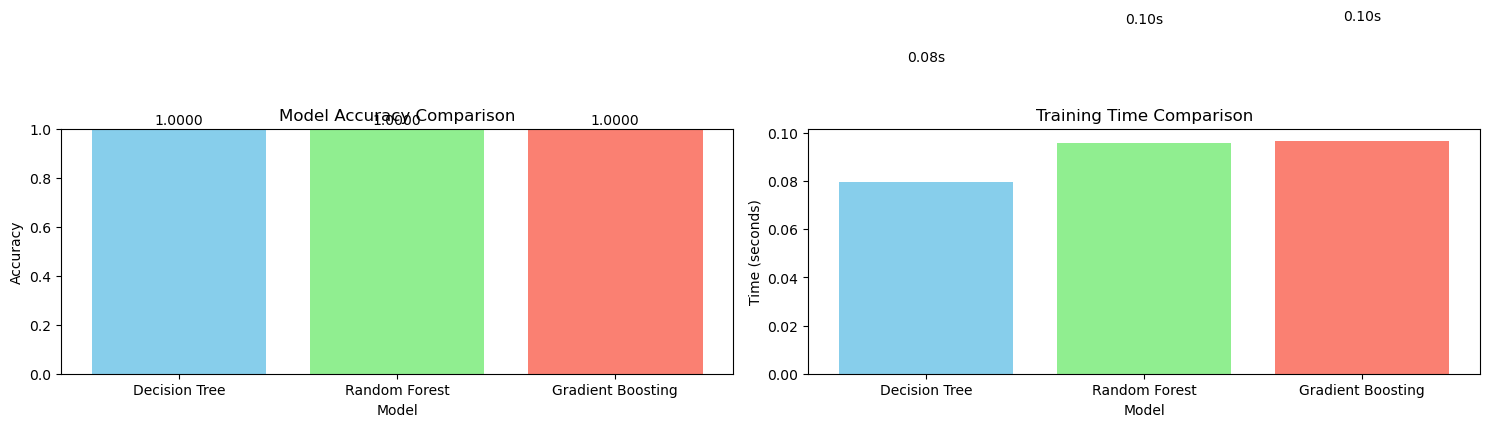

In [10]:
# Create a performance comparison visualizations
models = ["Decision Tree", "Random Forest", "Gradient Boosting"]
accuracies = [dt_accuracy, rf_accuracy, gbt_accuracy]
train_times = [dt_time, rf_time, gbt_time]

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot accuracies
ax1.bar(models, accuracies, color=['skyblue', 'lightgreen', 'salmon'])
ax1.set_title('Model Accuracy Comparison')
ax1.set_xlabel('Model')
ax1.set_ylabel('Accuracy')
ax1.set_ylim([0, 1])
for i, acc in enumerate(accuracies):
    ax1.text(i, acc + 0.02, f'{acc:.4f}', ha='center')

# Plot training times
ax2.bar(models, train_times, color=['skyblue', 'lightgreen', 'salmon'])
ax2.set_title('Training Time Comparison')
ax2.set_xlabel('Model')
ax2.set_ylabel('Time (seconds)')
for i, t in enumerate(train_times):
    ax2.text(i, t + 0.05, f'{t:.2f}s', ha='center')

plt.tight_layout()
plt.show()

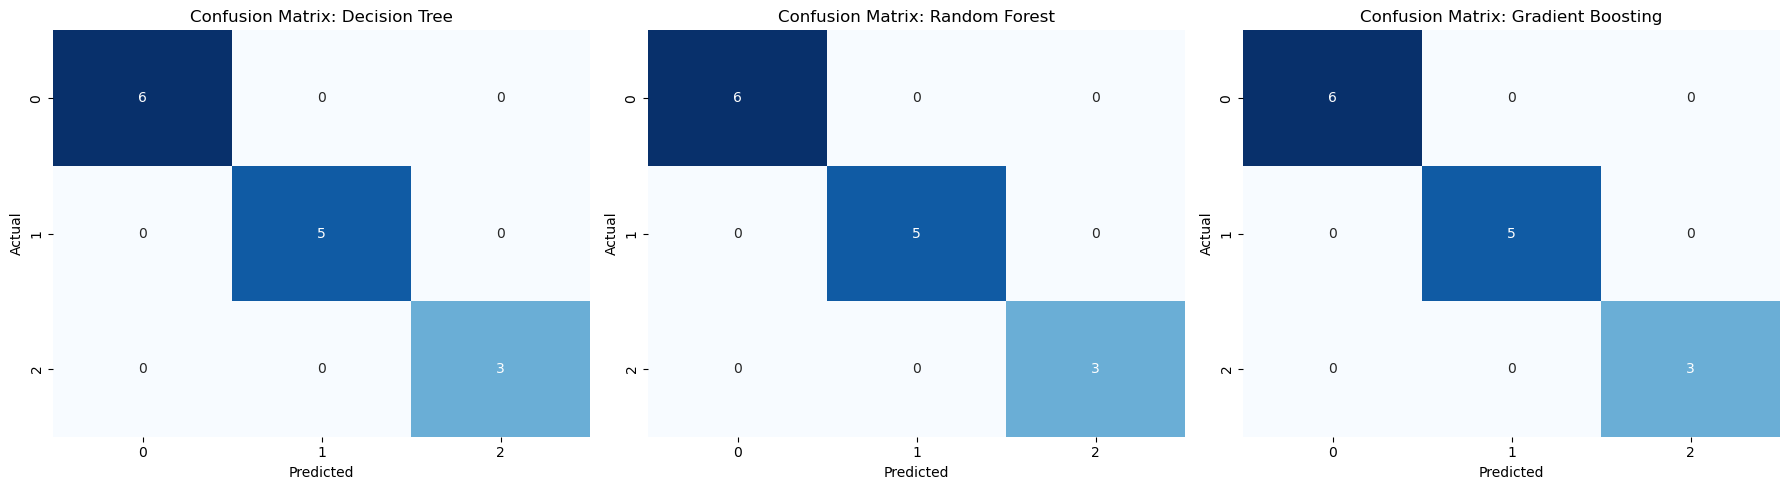

In [11]:
 # Create a figure for side-by-side comparison of confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Function to plot a confusion matrix
def plot_confusion_matrix(cm, title, ax):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(f'Confusion Matrix: {title}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

# Plot all three confusion matrices
plot_confusion_matrix(dt_cm, "Decision Tree", axes[0])
plot_confusion_matrix(rf_cm, "Random Forest", axes[1])
plot_confusion_matrix(gbt_cm, "Gradient Boosting", axes[2])

plt.tight_layout()
plt.show()

In [12]:
# Let's summarize our findings from both approaches
import pandas as pd

# Create a summary DataFrame comparing Dask ML vs Spark ML
# You'll need to manually input the Spark ML results from Part A
comparison_data = {
    'Model': ['Decision Tree', 'Random Forest', 'Gradient Boosting'],
    'Dask ML Accuracy': [dt_accuracy, rf_accuracy, gbt_accuracy],
    'Spark ML Accuracy': [0.0, 0.0, 0.0]  # Replace with your Part A results
}

comparison_df = pd.DataFrame(comparison_data)
display(comparison_df)

print("""
Key observations:
1. [Your findings about model accuracy differences]
2. [Your findings about speed/performance differences]
3. [Your findings about ease of implementation/API differences]
""")

,Model,Dask ML Accuracy,Spark ML Accuracy
0,Decision Tree,1.0,0.0
1,Random Forest,1.0,0.0
2,Gradient Boosting,1.0,0.0



Key observations:
1. [Your findings about model accuracy differences]
2. [Your findings about speed/performance differences]
3. [Your findings about ease of implementation/API differences]

